In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

matches = pd.read_parquet('../data/matches.parquet')
print(f"human_matches: {len(matches)}")
print(matches.head())

human_matches: 365654
   id1           id2  target
0   32  188978721454     0.0
1   34  197568543106     0.0
2   37  661425040668     0.0
3   97  274877917548     0.0
4  154  283467899529     0.0


In [3]:
items = pd.read_parquet('../data/items_human.parquet')
print(f"human_items: {len(items)}")
print(items.head())
print()

#все ли id из пар есть в items
ids_in_pairs = set(matches['id1']).union(set(matches['id2']))
ids_in_items = set(items['id'])
missing = ids_in_pairs - ids_in_items
print(f"id not in items_human: {len(missing)}")

human_items: 711304
     id                                               name  \
0   197  victor reinz прокладка впускного коллектора ар...   
1   415             stellox диск тормозной, арт. 8500892sx   
2   427        комплект подшипника ступицы колеса lynxauto   
3  1027      kraft подшипник ступицы, арт. kt204632, 1 шт.   
4  2639                    фильтр салонный skoda fabia 00-   

                                          attributes    category  
0  {"артикул":"703315700","бренд":"victor reinz",...  Автотовары  
1  {"артикул":"stellox_8500892sx","место установк...  Автотовары  
2  {"артикул производителя":"","бренд":"lynxauto"...  Автотовары  
3  {"артикул":"112097-01","бренд":"kraft","количе...  Автотовары  
4  {"альтернативные артикулы товара":"8104400xkz9...  Автотовары  

id not in items_human: 0


In [6]:
print(items['attributes'][0])
print(items['attributes'][1])
print(items['attributes'][2])

{"артикул":"703315700","бренд":"victor reinz","партномер (артикул производителя)":"703315700","тип":"прокладка двигателя","вид техники":"легковые автомобили"}
{"артикул":"stellox_8500892sx","место установки":"передние","толщина тормозного диска, мм":"28","бренд":"stellox","oem-номер":"3050086; a9064210012; 2e0615301; 68006716aa; 9064210012; 9064210212; 9064210012s; 9064210112","партномер (артикул производителя)":"8500892sx","тип":"диск тормозной","тип тормозного диска":"вентилируемый","вид техники":"легковые автомобили"}
{"артикул производителя":"","бренд":"lynxauto","примечание":"внешний вид изделия может отличаться от фотографий","цена за":"1 шт.","код товара":"600000256748"}


In [8]:

print("пропуски в matches:\n", matches.isnull().sum())

print("пропуски в items:\n", items.isnull().sum())

dup_pairs = matches.duplicated(subset=['id1', 'id2']).sum()
print(f"дубли: {dup_pairs}")

dup_groups = matches.groupby(['id1', 'id2'])['target'].nunique()
conflicts = (dup_groups > 1).sum()
print(f"пар с противоречием: {conflicts}")


пропуски в matches:
 id1       0
id2       0
target    0
dtype: int64
пропуски в items:
 id            0
name          0
attributes    0
category      0
dtype: int64
дубли: 0
пар с противоречием: 0


target
0.0    271764
1.0     93890
Name: count, dtype: int64
target=1: 25.68%


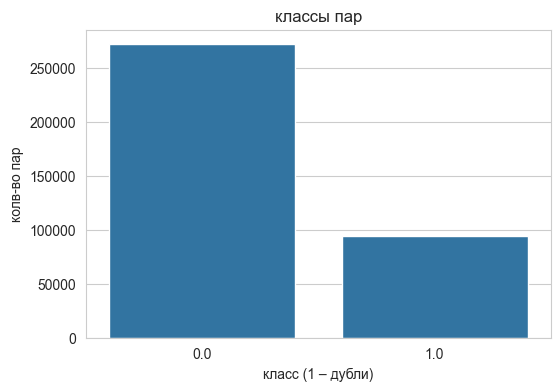

In [11]:
target_counts = matches['target'].value_counts()
print(target_counts)
print(f"target=1: {target_counts[1] / len(matches):.2%}")

plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('классы пар')
plt.xlabel('класс (1 – дубли)')
plt.ylabel('колв-во пар')
plt.show()

Пропуски cat1: 0, cat2: 0


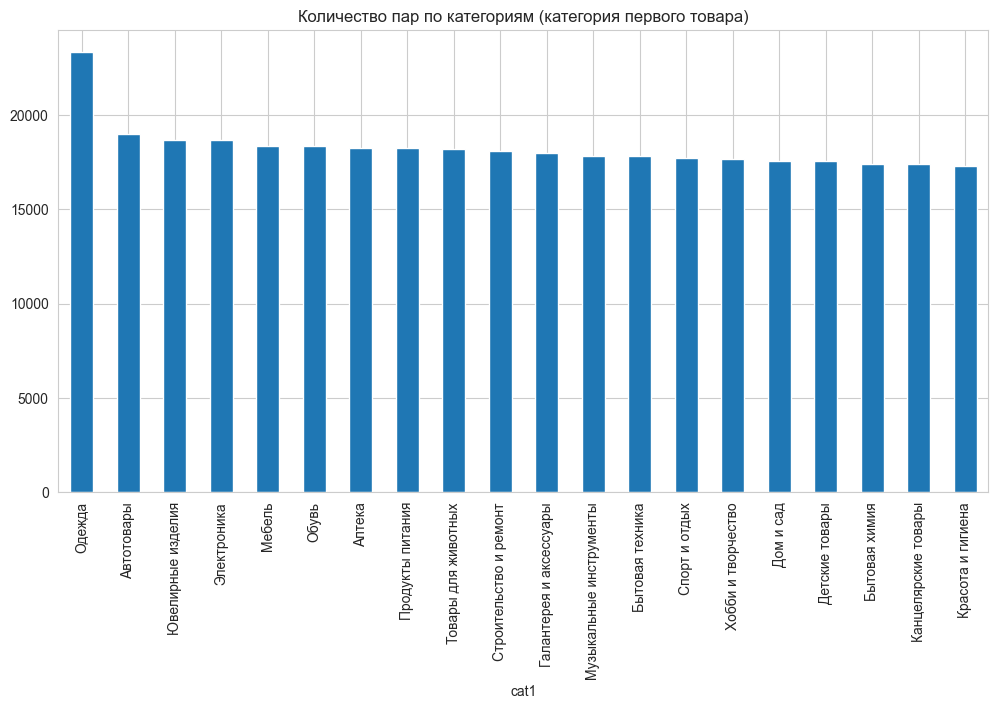

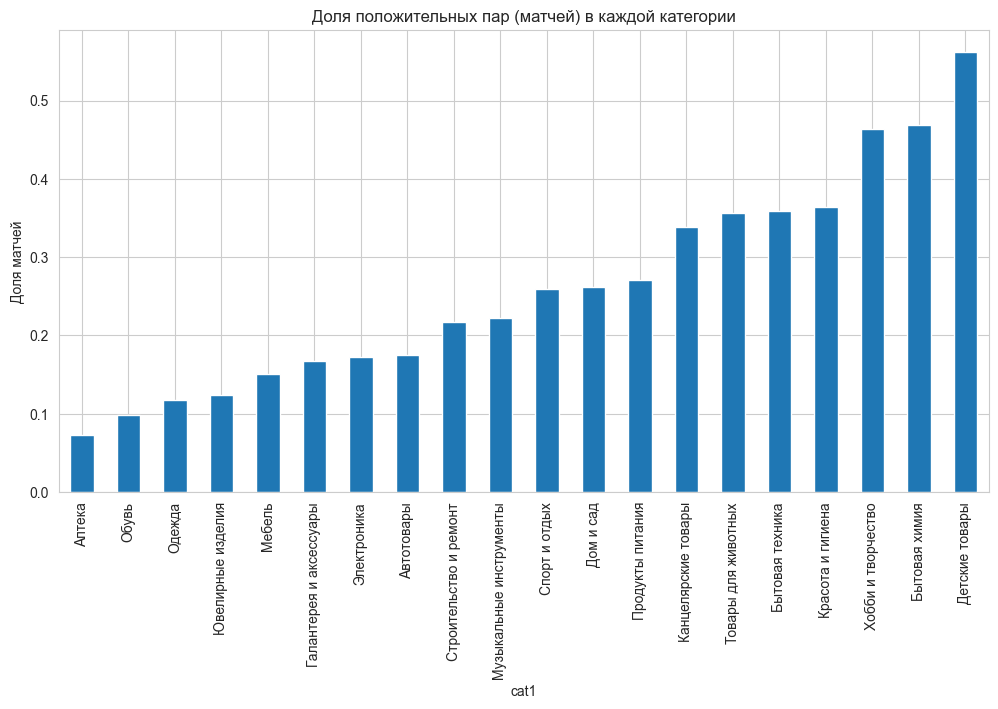

Доля классов при совпадении/несовпадении категорий:
 target          0.0       1.0
cat_match                    
True       0.743227  0.256773


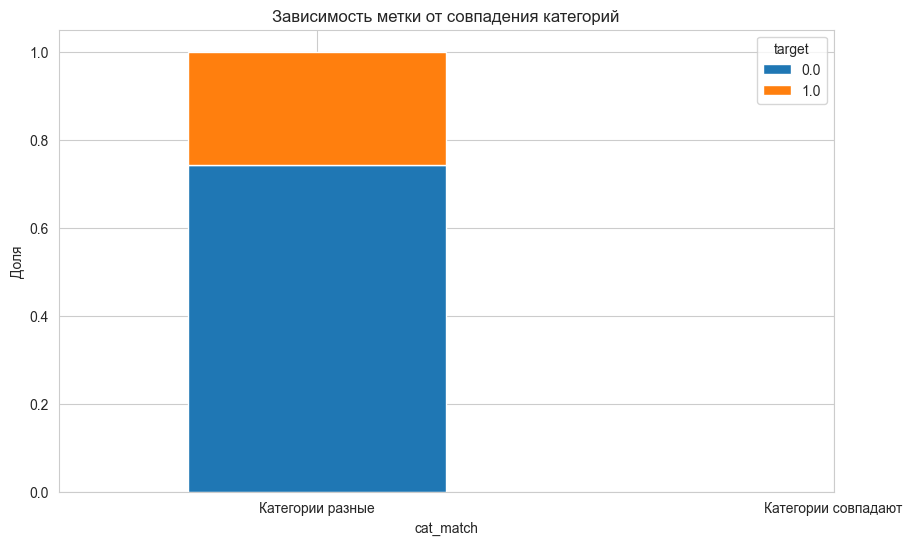

In [12]:
# Добавим категории товаров к парам (берём категорию первого товара)
matches = matches.merge(items[['id', 'category']], left_on='id1', right_on='id', how='left')
matches.rename(columns={'category': 'cat1'}, inplace=True)
matches = matches.merge(items[['id', 'category']], left_on='id2', right_on='id', how='left')
matches.rename(columns={'category': 'cat2'}, inplace=True)

# Сколько пар с неизвестной категорией?
print(f"Пропуски cat1: {matches['cat1'].isnull().sum()}, cat2: {matches['cat2'].isnull().sum()}")

# Распределение пар по категориям (cat1)
plt.figure(figsize=(12,6))
matches['cat1'].value_counts().plot(kind='bar')
plt.title('Количество пар по категориям (категория первого товара)')
plt.xticks(rotation=90)
plt.show()

# Доля матчей внутри каждой категории
cat_match_rate = matches.groupby('cat1')['target'].mean().sort_values()
plt.figure(figsize=(12,6))
cat_match_rate.plot(kind='bar')
plt.title('Доля положительных пар (матчей) в каждой категории')
plt.xticks(rotation=90)
plt.ylabel('Доля матчей')
plt.show()

# Совпадают ли категории у товаров в паре?
matches['cat_match'] = (matches['cat1'] == matches['cat2'])
cat_match_crosstab = pd.crosstab(matches['cat_match'], matches['target'], normalize='index')
print("Доля классов при совпадении/несовпадении категорий:\n", cat_match_crosstab)

cat_match_crosstab.plot(kind='bar', stacked=True)
plt.title('Зависимость метки от совпадения категорий')
plt.xticks([0,1], ['Категории разные', 'Категории совпадают'], rotation=0)
plt.ylabel('Доля')
plt.show()

новые признаки из items.attributes

In [ ]:
from collections import Counter

#все ключи из всех attributes
key_counter = Counter()
for attr in items['attributes']:
    try:
        data = json.loads(attr)
        key_counter.update(data.keys())
    except:
        pass

# Топ-20 самых частых ключей
print(len(key_counter))
print(key_counter.most_common(20))

34112
[('тип', 439850), ('бренд', 369084), ('страна-изготовитель', 284015), ('комплектация', 265396), ('цвет товара', 257188), ('валюта', 163743), ('страна производства', 152058), ('пол', 133153), ('материал', 120393), ('состав', 113295), ('цвет', 103681), ('вес товара, г', 103303), ('название цвета', 101464), ('гарантийный срок', 97461), ('артикул', 94702), ('коллекция', 83591), ('длина упаковки', 72678), ('высота упаковки', 72575), ('ширина упаковки', 72547), ('упаковка', 72518)]
